# Sigmoid Function and Bernoulli Distribution: Foundations of Binary Classification

## Overview

The **sigmoid function** and **Bernoulli distribution** are intimately connected and form the mathematical foundation for binary classification, logistic regression, and neural networks with binary outputs.

### Why This Connection Matters?

1. **Bernoulli models binary outcomes** - Success/failure, yes/no, 0/1 problems
2. **Sigmoid outputs probabilities** - Maps any real number to (0,1) interval
3. **Perfect pairing** - Sigmoid probability = Bernoulli parameter
4. **MLE foundation** - Leads directly to logistic regression
5. **Neural networks** - Sigmoid/logistic neurons are building blocks
6. **Deep learning** - Understanding this connection clarifies why we use these functions

### Key Insight

The sigmoid function $\sigma(z) = \frac{1}{1+e^{-z}}$ is **perfectly designed** to be the probability parameter $p$ of a Bernoulli distribution. When we predict $p = \sigma(\theta^T x)$ for a binary outcome $y \in \{0, 1\}$, we're modeling:

$$P(y | x; \theta) = \sigma(\theta^T x)^y (1 - \sigma(\theta^T x))^{1-y}$$

This is **Bernoulli likelihood**, and maximizing it gives us logistic regression.

---

## Section 1: Bernoulli Distribution Fundamentals

### 1.1 Definition

A **Bernoulli distribution** models a random variable that takes exactly two values:

$$Y \sim \text{Bernoulli}(p) \quad \text{where} \quad Y \in \{0, 1\}$$

**Parameter**: $p \in [0, 1]$ is the probability of success (outcome = 1)

**Examples in practice**:
- Email: spam (1) or not spam (0)
- Medical: disease present (1) or absent (0)
- Finance: loan default (1) or repayment (0)
- ML: prediction correct (1) or incorrect (0)

### 1.2 Probability Mass Function (PMF)

For $y \in \{0, 1\}$:

$$P(Y = y | p) = p^y (1-p)^{1-y}$$

**Equivalently**:
- $P(Y = 1 | p) = p$ (success probability)
- $P(Y = 0 | p) = 1 - p$ (failure probability)

**Why this form?** The formula $p^y (1-p)^{1-y}$ is clever:
- When $y = 1$: gives $p^1 (1-p)^0 = p$
- When $y = 0$: gives $p^0 (1-p)^1 = 1-p$
- Single compact formula handles both cases

### 1.3 Key Statistics

| Statistic | Formula | Interpretation |
|-----------|---------|----------------|
| **Mean** | $E[Y] = p$ | Expected outcome value |
| **Variance** | $\text{Var}(Y) = p(1-p)$ | Spread is maximized at $p=0.5$ |
| **Mode** | $p > 0.5 \Rightarrow 1$; $p < 0.5 \Rightarrow 0$ | Most likely outcome |

**Note on variance**: $\text{Var}(Y) = p(1-p)$ reaches maximum 0.25 at $p = 0.5$ (highest uncertainty)

### 1.4 Why Only Two Values?

The Bernoulli distribution is the **simplest discrete distribution**:
- Only one parameter ($p$) specifies it completely
- Only two outcomes possible
- Sum of Bernoulli trials (i.i.d.) gives **Binomial distribution**

---

## Section 2: The Sigmoid (Logistic) Function

### 2.1 Definition

The **sigmoid function** (also called logistic function):

$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}$$

**Domain**: $z \in (-\infty, +\infty)$ (all real numbers)

**Range**: $\sigma(z) \in (0, 1)$ (open interval)

### 2.2 Key Properties

| Property | Formula | Why Important |
|----------|---------|---------------|
| **Symmetry** | $\sigma(-z) = 1 - \sigma(z)$ | Symmetric around $z=0$ |
| **At origin** | $\sigma(0) = 0.5$ | Neutral point |
| **Limits** | $\lim_{z \to \infty} \sigma(z) = 1$ | Approaches 1 \& 0 asymptotically |
| **Derivative** | $\frac{d\sigma}{dz} = \sigma(z)(1-\sigma(z))$ | Smooth, bounded |
| **Log-odds** | $\log\frac{\sigma(z)}{1-\sigma(z)} = z$ | Linear in input |

### 2.3 Interpretation as Probability

When applied to predictions:
$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**Interpretation**:
- $z$ = log-odds (unbounded)
- $p$ = probability of class 1 (bounded to [0,1])
- Converts unbounded linear predictor into valid probability

**Why sigmoid specifically?** It's the inverse of the logit function:
$$\text{logit}(p) = \log\frac{p}{1-p} = z$$

So: $\sigma(z) = \text{logit}^{-1}(z)$

---

## Section 3: The Mathematical Connection

### 3.1 Combining Sigmoid and Bernoulli

**The key insight**: Use sigmoid output as Bernoulli probability parameter

Given features $x$ and parameters $\theta$:

1. **Compute linear combination**: $z = \theta^T x$
2. **Apply sigmoid**: $p = \sigma(\theta^T x) = \frac{1}{1+e^{-\theta^T x}}$
3. **Model as Bernoulli**: $y \sim \text{Bernoulli}(p)$

**Result**: The probability of observing label $y$ given features $x$:

$$P(y | x; \theta) = \sigma(\theta^T x)^y (1 - \sigma(\theta^T x))^{1-y}$$

### 3.2 Why This Works Perfectly

| Requirement | Sigmoid Provides | Bernoulli Needs |
|------------|------------------|----------------|
| **Input** | Takes any real $z \in \mathbb{R}$ | Linear predictor $\theta^T x$ |
| **Output** | Produces $p \in (0, 1)$ | Probability parameter $p \in (0,1)$ |
| **Smoothness** | Differentiable everywhere | Needed for gradient-based optimization |
| **Asymptotes** | Approaches 0 and 1 | Natural for probabilities |
| **Monotonic** | Monotonically increasing | Preserves ordering |

**No coincidence!** Sigmoid was specifically designed for this purpose.

### 3.3 Alternative Form: Using Log-Odds

**If** we think in terms of log-odds:

$$\log\frac{p}{1-p} = \theta^T x$$

Then:
$$p = \frac{e^{\theta^T x}}{1 + e^{\theta^T x}} = \sigma(\theta^T x)$$

**Interpretation**: The log-odds of class 1 are linear in features!

---

## Section 4: Connection to Maximum Likelihood

### 4.1 Likelihood Function

Given data $(X, \mathbf{y})$ where $y_i \in \{0, 1\}$:

$$L(\theta) = \prod_{i=1}^{n} P(y_i | x_i; \theta) = \prod_{i=1}^{n} \sigma(\theta^T x_i)^{y_i} (1 - \sigma(\theta^T x_i))^{1-y_i}$$

### 4.2 Log-Likelihood

$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \left[ y_i \log \sigma(\theta^T x_i) + (1-y_i) \log(1 - \sigma(\theta^T x_i)) \right]$$

This is the **Binary Cross-Entropy** loss function!

### 4.3 Connection to Logistic Regression

**Maximum Likelihood Estimation** for this model:

$$\hat{\theta}_{MLE} = \arg\max_\theta \ell(\theta)$$

**Equivalently** (minimizing negative log-likelihood):

$$\hat{\theta}_{MLE} = \arg\min_\theta -\ell(\theta) = \arg\min_\theta \text{BCE}(\theta)$$

**This is Logistic Regression!**

---

## Section 5: Visualization and Intuition

SIGMOID FUNCTION AND BERNOULLI DISTRIBUTION


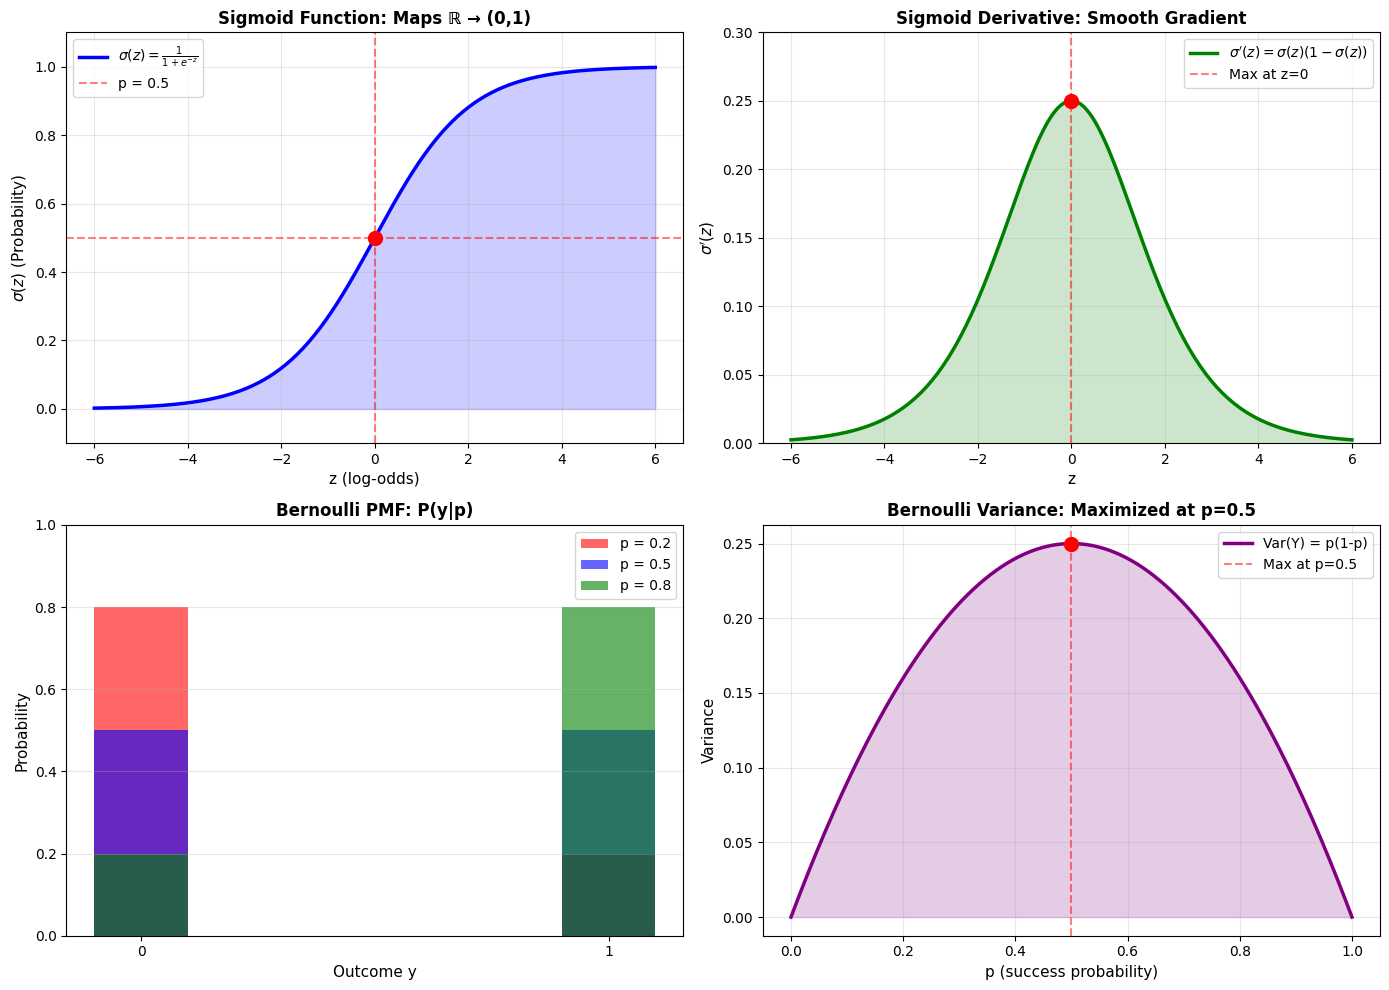


Key observations:
1. Sigmoid is S-shaped, smoothly transitioning from 0 to 1
2. Sigmoid derivative is bell-shaped, peaked at z=0
3. Bernoulli PMF depends entirely on single parameter p
4. Variance p(1-p) is highest when p=0.5 (maximum uncertainty)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # Numerically stable sigmoid

print("="*80)
print("SIGMOID FUNCTION AND BERNOULLI DISTRIBUTION")
print("="*80)

# Plot 1: Sigmoid function
z = np.linspace(-6, 6, 200)
sigmoid_z = expit(z)  # scipy's numerically stable sigmoid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Sigmoid function
ax = axes[0, 0]
ax.plot(z, sigmoid_z, 'b-', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='p = 0.5')
ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)
ax.scatter([0], [0.5], s=100, color='red', zorder=5)
ax.fill_between(z, 0, sigmoid_z, alpha=0.2, color='blue')
ax.set_xlabel('z (log-odds)', fontsize=11)
ax.set_ylabel(r'$\sigma(z)$ (Probability)', fontsize=11)
ax.set_title('Sigmoid Function: Maps ℝ → (0,1)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([-0.1, 1.1])

# Panel 2: Sigmoid derivative
ax = axes[0, 1]
sigmoid_prime = sigmoid_z * (1 - sigmoid_z)
ax.plot(z, sigmoid_prime, 'g-', linewidth=2.5, label=r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$")
ax.fill_between(z, 0, sigmoid_prime, alpha=0.2, color='green')
ax.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Max at z=0')
ax.scatter([0], [0.25], s=100, color='red', zorder=5)
ax.set_xlabel('z', fontsize=11)
ax.set_ylabel(r"$\sigma'(z)$", fontsize=11)
ax.set_title('Sigmoid Derivative: Smooth Gradient', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0, 0.3])

# Panel 3: Bernoulli PMF for different p values
ax = axes[1, 0]
p_values = [0.2, 0.5, 0.8]
x_vals = [0, 1]
colors_p = ['red', 'blue', 'green']

for p, color in zip(p_values, colors_p):
    pmf = np.array([1-p, p])
    ax.bar(x_vals, pmf, width=0.2, alpha=0.6, label=f'p = {p}', color=color)

ax.set_xlabel('Outcome y', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Bernoulli PMF: P(y|p)', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_ylim([0, 1])
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Panel 4: Variance of Bernoulli
ax = axes[1, 1]
p_range = np.linspace(0, 1, 200)
variance = p_range * (1 - p_range)
ax.plot(p_range, variance, 'purple', linewidth=2.5, label=r'Var(Y) = p(1-p)')
ax.fill_between(p_range, 0, variance, alpha=0.2, color='purple')
ax.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='Max at p=0.5')
ax.scatter([0.5], [0.25], s=100, color='red', zorder=5)
ax.set_xlabel('p (success probability)', fontsize=11)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Bernoulli Variance: Maximized at p=0.5', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("1. Sigmoid is S-shaped, smoothly transitioning from 0 to 1")
print("2. Sigmoid derivative is bell-shaped, peaked at z=0")
print("3. Bernoulli PMF depends entirely on single parameter p")
print("4. Variance p(1-p) is highest when p=0.5 (maximum uncertainty)")

---

## Section 6: Sigmoid and Bernoulli in Practice

### 6.1 Binary Classification Pipeline

```
Feature Vector x
     ↓
Linear Combination: z = θ^T x
     ↓
Apply Sigmoid: p = σ(z) ∈ (0,1)
     ↓
Model as Bernoulli: P(y=1|x;θ) = p, P(y=0|x;θ) = 1-p
     ↓
Predict: ŷ = argmax{P(y=0|x;θ), P(y=1|x;θ)}
     ↓
Optimize: max_θ log-likelihood = min_θ binary cross-entropy
```

### 6.2 Decision Boundary

**Decision rule** (with threshold 0.5):
- Predict $\hat{y} = 1$ if $\sigma(\theta^T x) > 0.5$
- Predict $\hat{y} = 0$ if $\sigma(\theta^T x) < 0.5$

**Equivalently** (using log-odds):
- Predict $\hat{y} = 1$ if $\theta^T x > 0$
- Predict $\hat{y} = 0$ if $\theta^T x < 0$

The decision boundary is **linear** in the original feature space!

### 6.3 Loss Function Derivation

**Negative log-likelihood** (Binary Cross-Entropy):

$$\text{BCE}(\theta) = -\sum_{i=1}^{n} \left[ y_i \log \sigma(\theta^T x_i) + (1-y_i) \log(1 - \sigma(\theta^T x_i)) \right]$$

**For single sample**:
- If $y_i = 1$: Loss $= -\log p_i$ (penalizes low predicted probability)
- If $y_i = 0$: Loss $= -\log(1-p_i)$ (penalizes high predicted probability)

**Why this form?** Comes naturally from Bernoulli likelihood!

---

## Section 7: Detailed Code Example

PRACTICAL EXAMPLE: LOGISTIC REGRESSION WITH SIGMOID + BERNOULLI

Data Summary:
  Shape: (100, 2) samples
  Classes: [0. 1.]
  Class distribution: [50 50]

Training Logistic Regression...
  Iteration   0: Loss = 0.6931
  Iteration  20: Loss = 0.0862
  Iteration  40: Loss = 0.0504
  Iteration  60: Loss = 0.0367
  Iteration  80: Loss = 0.0292
  Iteration 100: Loss = 0.0247

Training Accuracy: 100.00%

Sample Predictions (first 10):
  Index | True | P(y=1) | Prediction
  ----------------------------------------
    0   | 0    | 0.017  | 0
    1   | 0    | 0.115  | 0
    2   | 0    | 0.007  | 0
    3   | 0    | 0.137  | 0
    4   | 0    | 0.012  | 0
    5   | 0    | 0.004  | 0
    6   | 0    | 0.002  | 0
    7   | 0    | 0.001  | 0
    8   | 0    | 0.005  | 0
    9   | 0    | 0.001  | 0


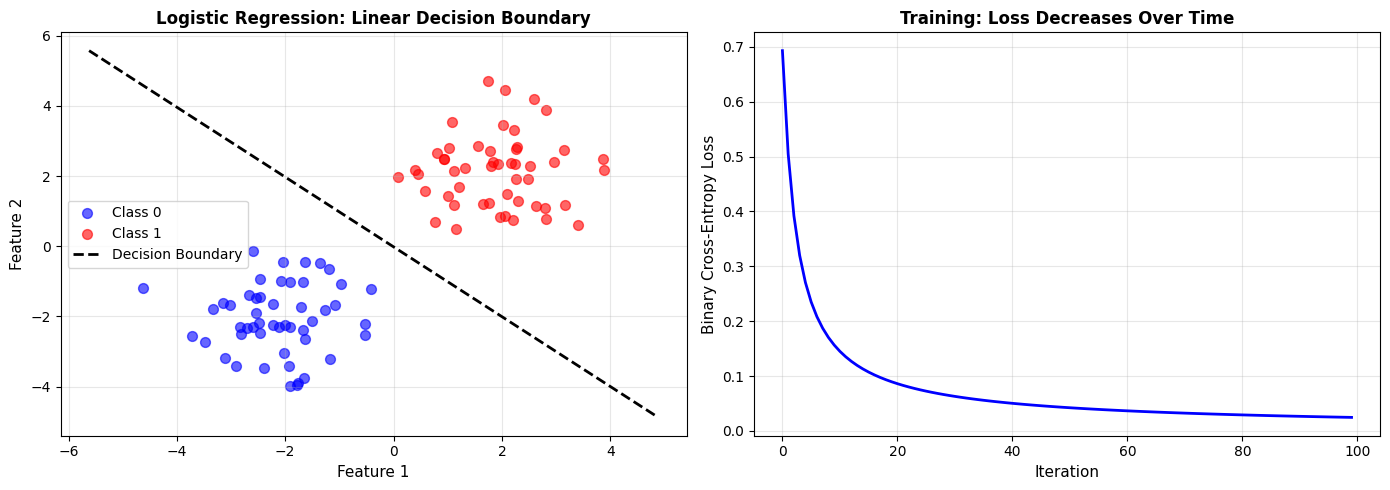


HOW THIS DEMONSTRATES THE CONNECTION:
1. We modeled: P(y|x; θ) = σ(θ'x)^y * (1-σ(θ'x))^(1-y)  [Bernoulli with Sigmoid]
2. Maximized likelihood by minimizing binary cross-entropy
3. Sigmoid outputs probability p ∈ (0,1) for Bernoulli parameter
4. Linear decision boundary in feature space comes naturally
5. This is the foundation of logistic regression!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

print("="*80)
print("PRACTICAL EXAMPLE: LOGISTIC REGRESSION WITH SIGMOID + BERNOULLI")
print("="*80)

# Generate synthetic binary classification data
np.random.seed(42)

# Class 0: centered at (0, 0)
X_class0 = np.random.randn(50, 2) + np.array([-2, -2])
y_class0 = np.zeros(50)

# Class 1: centered at (2, 2)
X_class1 = np.random.randn(50, 2) + np.array([2, 2])
y_class1 = np.ones(50)

# Combine
X = np.vstack([X_class0, X_class1])
y = np.hstack([y_class0, y_class1])

# Add intercept term
X_with_intercept = np.column_stack([np.ones(len(X)), X])

print("\nData Summary:")
print(f"  Shape: {X.shape} samples")
print(f"  Classes: {np.unique(y)}")
print(f"  Class distribution: {np.bincount(y.astype(int))}")

# Fit logistic regression (simplified gradient descent)
def sigmoid(z):
    return expit(z)  # Numerically stable

def binary_cross_entropy(X, y, theta):
    """Compute BCE loss"""
    z = X @ theta
    p = sigmoid(z)
    eps = 1e-10  # Numerical stability
    return -np.mean(y * np.log(p + eps) + (1-y) * np.log(1-p + eps))

def logistic_gradient(X, y, theta):
    """Compute gradient of BCE loss"""
    z = X @ theta
    p = sigmoid(z)
    return X.T @ (p - y) / len(y)

# Gradient descent
theta = np.zeros(X_with_intercept.shape[1])
learning_rate = 0.1
n_iterations = 100
history = []

print("\nTraining Logistic Regression...")
for iteration in range(n_iterations):
    loss = binary_cross_entropy(X_with_intercept, y, theta)
    grad = logistic_gradient(X_with_intercept, y, theta)
    theta = theta - learning_rate * grad
    history.append(loss)
    
    if iteration % 20 == 0:
        print(f"  Iteration {iteration:3d}: Loss = {loss:.4f}")

print(f"  Iteration {n_iterations:3d}: Loss = {history[-1]:.4f}")

# Predictions
z_pred = X_with_intercept @ theta
p_pred = sigmoid(z_pred)
y_pred = (p_pred > 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred == y)
print(f"\nTraining Accuracy: {accuracy:.2%}")

# Show predictions on some samples
print("\nSample Predictions (first 10):")
print("  Index | True | P(y=1) | Prediction")
print("  " + "-"*40)
for i in range(10):
    print(f"  {i:3d}   | {int(y[i])}    | {p_pred[i]:.3f}  | {y_pred[i]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data and decision boundary
ax = axes[0]
ax.scatter(X_class0[:, 0], X_class0[:, 1], c='blue', label='Class 0', s=50, alpha=0.6)
ax.scatter(X_class1[:, 0], X_class1[:, 1], c='red', label='Class 1', s=50, alpha=0.6)

# Decision boundary: θ0 + θ1*x1 + θ2*x2 = 0
x1_range = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
# Solve for x2: θ2*x2 = -θ0 - θ1*x1
x2_boundary = -(theta[0] + theta[1]*x1_range) / theta[2]
ax.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Decision Boundary')

ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Logistic Regression: Linear Decision Boundary', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Plot 2: Training loss
ax = axes[1]
ax.plot(history, 'b-', linewidth=2)
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=11)
ax.set_title('Training: Loss Decreases Over Time', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HOW THIS DEMONSTRATES THE CONNECTION:")
print("="*80)
print("1. We modeled: P(y|x; θ) = σ(θ'x)^y * (1-σ(θ'x))^(1-y)  [Bernoulli with Sigmoid]")
print("2. Maximized likelihood by minimizing binary cross-entropy")
print("3. Sigmoid outputs probability p ∈ (0,1) for Bernoulli parameter")
print("4. Linear decision boundary in feature space comes naturally")
print("5. This is the foundation of logistic regression!")

---

## Section 8: Theoretical Connections

### 8.1 Sigmoid as Inverse Logit

**Logit function** (maps probabilities to log-odds):
$$\text{logit}(p) = \log\frac{p}{1-p}$$

**Sigmoid is the inverse**:
$$\sigma(z) = \text{logit}^{-1}(z) = \frac{1}{1+e^{-z}}$$

**Verification**:
$$\log\frac{\sigma(z)}{1-\sigma(z)} = \log\frac{\frac{1}{1+e^{-z}}}{\frac{e^{-z}}{1+e^{-z}}} = \log\frac{1}{e^{-z}} = z \quad \checkmark$$

### 8.2 Link Function Perspective

In **Generalized Linear Models (GLMs)**:

$$g(E[Y]) = \theta^T x$$

where $g$ is the **link function**.

**For Bernoulli response** with link $g = \text{logit}$:
$$\text{logit}(p) = \theta^T x$$
$$p = \sigma(\theta^T x)$$

This is **Logistic Regression** - a special case of GLM!

### 8.3 Connection to Exponential Family

**Bernoulli is in the exponential family**:
$$P(y|p) = p^y(1-p)^{1-y} = \exp(y\log p + (1-y)\log(1-p))$$

With canonical parameter $\eta = \log\frac{p}{1-p}$:
$$P(y|\eta) = \exp(y\eta - \log(1 + e^\eta))$$

The natural parameter $\eta = \theta^T x$ leads directly to sigmoid!

---

## Section 9: Comparison with Gaussian (Linear Regression)

### 9.1 Parallel Structure

**Linear Regression** (Gaussian outcome):
- Outcome: $y_i \sim N(\mu_i, \sigma^2)$ where $\mu_i = \theta^T x_i$
- Solution: Normal Equation (closed form)
- Loss: Sum of Squared Errors (MSE)

**Logistic Regression** (Bernoulli outcome):
- Outcome: $y_i \sim \text{Bernoulli}(p_i)$ where $p_i = \sigma(\theta^T x_i)$
- Solution: No closed form (need gradient descent)
- Loss: Binary Cross-Entropy

**Why the difference?**
- Gaussian: Quadratic loss → closed form solution
- Bernoulli: Cross-entropy loss → non-convex, iterative solution needed

---

## Section 10: Common Applications

### 10.1 Binary Classification Problems

| Domain | Application | Class 0 | Class 1 |
|--------|-------------|---------|----------|
| **Email** | Spam detection | Not spam | Spam |
| **Medical** | Disease diagnosis | Healthy | Disease |
| **Finance** | Credit risk | Safe | Default |
| **ML** | Fairness | Minority | Majority |
| **NLP** | Sentiment | Negative | Positive |

### 10.2 Probability Calibration

Logistic regression naturally provides well-calibrated probabilities:
- If model predicts $p = 0.7$ for a sample, approximately 70% of similar samples should be positive
- This comes from the Bernoulli assumption

---

## Section 11: Extension to Multi-Class (Softmax)

### 11.1 Multinomial Distribution

**Generalization of Bernoulli to $K$ classes**:

$$P(y = k | \mathbf{p}) = p_k \quad \text{where} \quad \sum_{k=1}^{K} p_k = 1$$

### 11.2 Softmax Function

**Generalization of sigmoid to $K$ classes**:

$$\sigma_k(\mathbf{z}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

- Maps $\mathbb{R}^K \to$ probability simplex
- When $K=2$, reduces to sigmoid
- Used in multi-class logistic regression

---

## Section 12: Key Takeaways and Summary

In [3]:
print("="*80)
print("SUMMARY: SIGMOID AND BERNOULLI RELATIONSHIP")
print("="*80)

summary = {
    "Bernoulli Distribution": [
        "• Simplest discrete distribution with two outcomes",
        "• Defined by single parameter p ∈ [0,1]",
        "• Mean = p, Variance = p(1-p)",
        "• Variance maximized at p = 0.5 (most uncertain)",
        "• Models binary outcomes: yes/no, 1/0, success/failure"
    ],
    "Sigmoid Function": [
        "• S-shaped curve mapping ℝ → (0,1)",
        "• Formula: σ(z) = 1/(1+e^(-z))",
        "• Smooth, differentiable everywhere",
        "• Derivative σ'(z) = σ(z)(1-σ(z)) is bell-shaped",
        "• Inverse of logit: σ = logit^(-1)"
    ],
    "Connection": [
        "• Sigmoid OUTPUT = Bernoulli PARAMETER",
        "• Model: y ~ Bernoulli(σ(θ'x))",
        "• Likelihood: P(y|x;θ) = σ(θ'x)^y (1-σ(θ'x))^(1-y)",
        "• MLE leads to logistic regression",
        "• Loss function: Binary Cross-Entropy"
    ],
    "Why This Matters": [
        "• Foundation of binary classification",
        "• Building block of neural networks",
        "• Well-calibrated probabilistic predictions",
        "• Generalizes to multi-class (softmax/multinomial)",
        "• Connects discrete and continuous mathematics"
    ]
}

for section, points in summary.items():
    print(f"\n{section}:")
    for point in points:
        print(f"  {point}")

print("\n" + "="*80)
print("DECISION TREE: When to Use Each")
print("="*80)
print("""
Question: What's your prediction problem?
├─ Continuous value (e.g., house price)
│  └─ Use Gaussian + Linear Regression
│
├─ Binary classification (e.g., spam/not spam)
│  └─ Use Bernoulli + Sigmoid + Logistic Regression
│
├─ Multi-class classification (e.g., digit 0-9)
│  └─ Use Multinomial + Softmax + Softmax Regression
│
└─ Count data (e.g., number of events)
   └─ Use Poisson + Exponential link
""")

print("\n" + "="*80)
print("MATHEMATICAL OBJECTS AND THEIR RELATIONSHIPS")
print("="*80)
print("""
Distribution    ↔  Link Function  ↔  Model
─────────────────────────────────────────────────────────────
Gaussian        ↔  Identity       ↔  Linear Regression
Bernoulli       ↔  Logit/Sigmoid ↔  Logistic Regression  ← YOU ARE HERE
Multinomial     ↔  Softmax       ↔  Multi-class Logistic
Poisson         ↔  Log           ↔  Poisson Regression
""")

print("\n" + "="*80)

SUMMARY: SIGMOID AND BERNOULLI RELATIONSHIP

Bernoulli Distribution:
  • Simplest discrete distribution with two outcomes
  • Defined by single parameter p ∈ [0,1]
  • Mean = p, Variance = p(1-p)
  • Variance maximized at p = 0.5 (most uncertain)
  • Models binary outcomes: yes/no, 1/0, success/failure

Sigmoid Function:
  • S-shaped curve mapping ℝ → (0,1)
  • Formula: σ(z) = 1/(1+e^(-z))
  • Smooth, differentiable everywhere
  • Derivative σ'(z) = σ(z)(1-σ(z)) is bell-shaped
  • Inverse of logit: σ = logit^(-1)

Connection:
  • Sigmoid OUTPUT = Bernoulli PARAMETER
  • Model: y ~ Bernoulli(σ(θ'x))
  • Likelihood: P(y|x;θ) = σ(θ'x)^y (1-σ(θ'x))^(1-y)
  • MLE leads to logistic regression
  • Loss function: Binary Cross-Entropy

Why This Matters:
  • Foundation of binary classification
  • Building block of neural networks
  • Well-calibrated probabilistic predictions
  • Generalizes to multi-class (softmax/multinomial)
  • Connects discrete and continuous mathematics

DECISION TREE: Whe

---

## References

### Foundational References

1. **Probability Theory**
   - Casella & Berger (2002). *Statistical Inference* (2nd ed.). Duxbury. Chapter 2-3: Probability and Distributions
   - Bernoulli distribution fundamentals and properties

2. **Logistic Regression**
   - Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Chapter 4: Linear Methods for Classification
   - Historical development of sigmoid/logistic function

3. **Generalized Linear Models**
   - McCullagh & Nelder (1989). *Generalized Linear Models* (2nd ed.). Chapman and Hall
   - Connection between Bernoulli, sigmoid, and GLM framework

4. **Deep Learning Perspective**
   - Goodfellow, Bengio & Courville (2016). *Deep Learning*. MIT Press. Chapter 6: Deep Feedforward Networks
   - Sigmoid activation functions in neural networks

### Historical Context

- Sigmoid function popularized in neural networks in the 1980s-1990s
- Logistic regression dates back to early 1900s as statistical tool
- Modern ML unified the probabilistic and computational perspectives

---

## Pedagogical Path

**Where This Fits in the ML 301 Sequence**:

```
ml_000_1: Introduction to Likelihood and Probability
    ↓
ml_000_2: Likelihood Functions (detailed)
    ↓
ml_000_3: Central Limit Theorem (why Gaussian is ubiquitous)
    ↓
ml_000_4: Least Squares + Gaussian (continuous outcomes)
    ↓
ml_000_5: Sigmoid + Bernoulli (binary outcomes) ← NOW HERE
    ↓
ml_001_*: Logistic Regression (putting it together)
    ↓
ml_001_*: Neural Networks (sigmoid as activation)
```

**Conceptual Journey**:
1. Started with likelihood as fundamental principle
2. Explored how different distributions lead to different models
3. Gaussian → Least Squares (continuous)
4. Bernoulli → Logistic (binary)
5. Both unified under MLE framework